## Tarea 1 EDA - Astrofísica y Big Data:
# Análisis exploratorio de datos sobre exoplanetas desde una perspectiva planetológica
### Úrsula Sáez, Jorge Luis Guzmán, Esteban Sánchez y Martín Raffo

# **1. Introducción**




### **Contexto**

En las últimas tres décadas, el estudio de exoplanetas se ha convertido en una de las áreas con mayor crecimiento en la astronomía, con más de seis mil exoplanetas descubiertos hasta la fecha. Son muchos los telescopios que han ayudado a su estudio y detección combinando distintos métodos, con proyectos como ALMA al norte de Chile, el satélite TESS, o el recientemente lanzado JWST. Entre los principales impulsos que le dan fuerza a estas investigaciones es la exploración de posibles exoplanetas aptos para la vida, donde es necesario examinar atmósferas, procesos de formación planetaria, la interacción de los planetas con sus respectivas estrellas, entre muchos otros parámetros.

Dada la gran y creciente cantidad de datos que hacen crecer la lista de exoplanetas no solo en número, sino que también en complejidad, utilizar herramientas desde la ciencia de datos que permitan analizar las observaciones de forma transversal se ha convertido en una práctica extendida y fundamental.


### **Objetivo del análisis**

En este proyecto se tiene como objetivo encontrar los tres mejores candidatos a planetas habitables usando un subconjunto de datos del catálogo *Habitable Worlds Catalog (HWC)*.
El enfoque que se utilizará para clasificar será desde la perspectiva planetológica, estudiando propiedades físicas como el radio, masa, densidad y gravedad superficial.

**Pregunta Guía**

¿Qué combinación de masa, radio y densidad hace más probable que un planeta retenga atmósfera y agua líquida?


# **2. Inspección y preparación de datos.**

In [ ]:
#librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2.1 Revisión de los datos

In [ ]:
# Leemos los datos y visualizamos las primeras filas y algunas columnas para saber de qué se tratan los datos
df = pd.read_csv("hwc.csv")
df.head()

,P_NAME,P_DETECTION,P_DISCOVERY_FACILITY,P_YEAR,P_UPDATE,P_MASS,P_MASS_ERROR_MIN,P_MASS_ERROR_MAX,P_MASS_LIMIT,P_MASS_ORIGIN,...,S_ABIO_ZONE,S_TIDAL_LOCK,P_HABZONE_OPT,P_HABZONE_CON,P_TYPE_TEMP,P_HABITABLE,P_ESI,S_CONSTELLATION,S_CONSTELLATION_ABR,S_CONSTELLATION_ENG
0,OGLE-2016-BLG-1227L b,Microlensing,OGLE,2020,2020-04-02,250.00,-120.0,413.0,0,Mass,...,NaN,0.214133,0,0,NaN,0,NaN,Scorpius,Sco,Scorpion
1,Kepler-276 c,Transit,Kepler,2013,2018-09-25,16.60,-3.6,4.4,0,Mass,...,2.097783,0.316980,0,0,Hot,0,0.272032,Cygnus,Cyg,Swan
2,Kepler-829 b,Transit,Kepler,2016,2019-04-16,5.10,NaN,NaN,0,M-R relationship,...,1.756317,0.459559,0,0,Hot,0,0.254763,Lyra,Lyr,Lyre
3,K2-283 b,Transit,K2,2018,2019-09-05,12.20,NaN,NaN,0,M-R relationship,...,0.568374,0.443760,0,0,Hot,0,0.193906,Pisces,Psc,Fishes
4,Kepler-477 b,Transit,Kepler,2016,2019-04-16,4.94,NaN,NaN,0,M-R relationship,...,0.768502,0.386150,0,0,Hot,0,0.276721,Lyra,Lyr,Lyre


In [ ]:
print(df.columns.tolist()) # Listado de todas las columnas/variables del dataset

['P_NAME', 'P_DETECTION', 'P_DISCOVERY_FACILITY', 'P_YEAR', 'P_UPDATE', 'P_MASS', 'P_MASS_ERROR_MIN', 'P_MASS_ERROR_MAX', 'P_MASS_LIMIT', 'P_MASS_ORIGIN', 'P_RADIUS', 'P_RADIUS_ERROR_MIN', 'P_RADIUS_ERROR_MAX', 'P_RADIUS_LIMIT', 'P_PERIOD', 'P_PERIOD_ERROR_MIN', 'P_PERIOD_ERROR_MAX', 'P_PERIOD_LIMIT', 'P_SEMI_MAJOR_AXIS', 'P_SEMI_MAJOR_AXIS_ERROR_MIN', 'P_SEMI_MAJOR_AXIS_ERROR_MAX', 'P_SEMI_MAJOR_AXIS_LIMIT', 'P_ECCENTRICITY', 'P_ECCENTRICITY_ERROR_MIN', 'P_ECCENTRICITY_ERROR_MAX', 'P_ECCENTRICITY_LIMIT', 'P_INCLINATION', 'P_INCLINATION_ERROR_MIN', 'P_INCLINATION_ERROR_MAX', 'P_INCLINATION_LIMIT', 'P_OMEGA', 'P_OMEGA_ERROR_MIN', 'P_OMEGA_ERROR_MAX', 'P_OMEGA_LIMIT', 'S_NAME', 'S_NAME_HD', 'S_NAME_HIP', 'S_TYPE', 'S_RA', 'S_DEC', 'S_RA_STR', 'S_DEC_STR', 'S_MAG', 'S_MAG_ERROR_MIN', 'S_MAG_ERROR_MAX', 'S_DISTANCE', 'S_DISTANCE_ERROR_MIN', 'S_DISTANCE_ERROR_MAX', 'S_TEMPERATURE', 'S_TEMPERATURE_ERROR_MIN', 'S_TEMPERATURE_ERROR_MAX', 'S_TEMPERATURE_LIMIT', 'S_MASS', 'S_MASS_ERROR_MIN', 'S_

In [ ]:
df.info()
print(f'Dimensiones del dataset: {df.shape[0]} planetas × {df.shape[1]} variables')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5599 entries, 0 to 5598
Columns: 118 entries, P_NAME to S_CONSTELLATION_ENG
dtypes: float64(81), int64(18), object(19)
memory usage: 5.0+ MB
Dimensiones del dataset: 5599 planetas × 118 variables


Observamos que el archivo tiene 5599 filas y 118 columnas, con 81 columnas "float", 18 columnas "int" y 19 columnas "object". Vemos que el dataset contiene el nombre de los exoplanetas, con informaciones como su método de detección y las diferentes propiedades físicas que estos poseen, incluyendo si se encuentran en la zona considerada habitable o no.

In [ ]:
nulos = df.isnull().sum() # Analizamos cuantos valores NaN hay en las columnas
print(nulos[nulos > 0])


P_MASS                   7
P_MASS_ERROR_MIN      3093
P_MASS_ERROR_MAX      3093
P_RADIUS                 7
P_RADIUS_ERROR_MIN    1752
                      ... 
S_SNOW_LINE            233
S_ABIO_ZONE            223
S_TIDAL_LOCK             4
P_TYPE_TEMP            234
P_ESI                  241
Length: 85, dtype: int64


In [ ]:
df.loc[:, df.isna().any()].columns # Identificamos qué columnas tienen al menos un dato NaN

Index(['P_MASS', 'P_MASS_ERROR_MIN', 'P_MASS_ERROR_MAX', 'P_RADIUS',
       'P_RADIUS_ERROR_MIN', 'P_RADIUS_ERROR_MAX', 'P_PERIOD',
       'P_PERIOD_ERROR_MIN', 'P_PERIOD_ERROR_MAX', 'P_SEMI_MAJOR_AXIS',
       'P_SEMI_MAJOR_AXIS_ERROR_MIN', 'P_SEMI_MAJOR_AXIS_ERROR_MAX',
       'P_ECCENTRICITY', 'P_ECCENTRICITY_ERROR_MIN',
       'P_ECCENTRICITY_ERROR_MAX', 'P_INCLINATION', 'P_INCLINATION_ERROR_MIN',
       'P_INCLINATION_ERROR_MAX', 'P_OMEGA', 'P_OMEGA_ERROR_MIN',
       'P_OMEGA_ERROR_MAX', 'S_NAME_HD', 'S_NAME_HIP', 'S_TYPE', 'S_MAG',
       'S_MAG_ERROR_MIN', 'S_MAG_ERROR_MAX', 'S_DISTANCE',
       'S_DISTANCE_ERROR_MIN', 'S_DISTANCE_ERROR_MAX', 'S_TEMPERATURE',
       'S_TEMPERATURE_ERROR_MIN', 'S_TEMPERATURE_ERROR_MAX', 'S_MASS',
       'S_MASS_ERROR_MIN', 'S_MASS_ERROR_MAX', 'S_RADIUS',
       'S_RADIUS_ERROR_MIN', 'S_RADIUS_ERROR_MAX', 'S_METALLICITY',
       'S_METALLICITY_ERROR_MIN', 'S_METALLICITY_ERROR_MAX', 'S_AGE',
       'S_AGE_ERROR_MIN', 'S_AGE_ERROR_MAX', 'S_LOG_LUM'

In [ ]:
df[df.duplicated(keep=False)] # Verificamos que no hayan columnas duplicadas

,P_NAME,P_DETECTION,P_DISCOVERY_FACILITY,P_YEAR,P_UPDATE,P_MASS,P_MASS_ERROR_MIN,P_MASS_ERROR_MAX,P_MASS_LIMIT,P_MASS_ORIGIN,...,S_ABIO_ZONE,S_TIDAL_LOCK,P_HABZONE_OPT,P_HABZONE_CON,P_TYPE_TEMP,P_HABITABLE,P_ESI,S_CONSTELLATION,S_CONSTELLATION_ABR,S_CONSTELLATION_ENG


Identificamos que la mayoría de columnas tienen datos NaN, en particular en cuanto a sus propiedades físicas se refiere, y que no hay columnas duplicadas. Es importante considerar esto para tener en cuenta posibles inconsistencias en el análisis.

## 2.2 Variables relevantes

Para retención de atmósfera:

| Variable | Descripción | Unidad |
|---|---|---|
| `P_MASS` | Masa del planeta | Masas terrestres (M⊕) |
| `P_MASS_ERROR_MIN` | Incertidumbre inferior de la masa | Masas terrestres (M⊕) |
| `P_MASS_ERROR_MAX` | Incertidumbre superior de la masa | Masas terrestres (M⊕) |
| `P_RADIUS` | Radio del planeta | Radios terrestres (R⊕) |
| `P_RADIUS_ERROR_MIN` | Incertidumbre inferior del radio | Radios terrestres (R⊕) |
| `P_RADIUS_ERROR_MAX` | Incertidumbre superior del radio | Radios terrestres (R⊕) |
| `P_DENSITY` | Densidad media del planeta | g/cm³ (normalizado a la Tierra) |
| `P_GRAVITY` | Gravedad superficial | g⊕ |
| `P_ESCAPE` | Velocidad de escape | km/s (normalizada a la Tierra) |
| `P_POTENTIAL` | Potencial gravitacional | Normalizado a la Tierra|
| `P_TYPE` | Tipo planetario (rocoso, joviano, etc...)| Categórica |
| `P_TEMP_EQUIL` | Temperatura de equilibrio | K |
| `P_HABITABLE` | Flag de habitabilidad | 0 = no, 1 = conservador, 2 = op|
| `P_ESI` | Índice de similitud terrestre | 0-1 |]



Para presentar agua en estado líquido:
| Variable | Descripción | Unidad |
|---|---|---|
| `P_TEMP_EQUIL` | Temperatura de equilibrio del planeta | K |
| `P_TEMP_EQUIL_MIN` | Incertidumbre inferior de la temperatura de equilibrio | K |
| `P_TEMP_EQUIL_MAX` | Incertidumbre superior de la temperatura de equilibrio | k |

Para la densidad, gravedad y velocidad de escape las unidades de medida fueron inferidas manualmente, utilizando los parámetros de masa y radio, ya que no se encuentran explícitamente en la base de datos.

## 2.3 Limpieza de datos

Siguiendo el enfoque planetológico del proyecto, optamos por trabajar con las variables que se relacionan con su clasificación como rocoso o gaseoso, la capacidad de retención atmosférica y la posibilidad de presentar agua en estado líquido. Estas son la masa del planeta, el radio, densidad, gravedad superficial, la temperatura de equilibrio y la velocidad de escape.

In [ ]:
# Ignoramos filas que no tengan datos en las variables de mayor interés
df_clean = df.dropna(subset=["P_MASS", "P_RADIUS", "P_DENSITY", "P_GRAVITY", "P_TEMP_EQUIL", "P_ESCAPE"])
df_clean

,P_NAME,P_DETECTION,P_DISCOVERY_FACILITY,P_YEAR,P_UPDATE,P_MASS,P_MASS_ERROR_MIN,P_MASS_ERROR_MAX,P_MASS_LIMIT,P_MASS_ORIGIN,...,S_ABIO_ZONE,S_TIDAL_LOCK,P_HABZONE_OPT,P_HABZONE_CON,P_TYPE_TEMP,P_HABITABLE,P_ESI,S_CONSTELLATION,S_CONSTELLATION_ABR,S_CONSTELLATION_ENG
1,Kepler-276 c,Transit,Kepler,2013,2018-09-25,16.60000,-3.60000,4.40000,0,Mass,...,2.097783,0.316980,0,0,Hot,0,0.272032,Cygnus,Cyg,Swan
2,Kepler-829 b,Transit,Kepler,2016,2019-04-16,5.10000,NaN,NaN,0,M-R relationship,...,1.756317,0.459559,0,0,Hot,0,0.254763,Lyra,Lyr,Lyre
3,K2-283 b,Transit,K2,2018,2019-09-05,12.20000,NaN,NaN,0,M-R relationship,...,0.568374,0.443760,0,0,Hot,0,0.193906,Pisces,Psc,Fishes
4,Kepler-477 b,Transit,Kepler,2016,2019-04-16,4.94000,NaN,NaN,0,M-R relationship,...,0.768502,0.386150,0,0,Hot,0,0.276721,Lyra,Lyr,Lyre
5,TOI-1260 c,Transit,Transiting Exoplanet Survey Satellite (TESS),2021,2022-12-17,13.20000,-4.23000,4.23000,0,Mass,...,0.124210,0.431924,0,0,Hot,0,0.260440,Ursa Major,UMa,Big Bear
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5592,TOI-1694 b,Transit,Transiting Exoplanet Survey Satellite (TESS),2023,2023-05-26,26.10000,-2.20000,2.20000,0,Mass,...,0.563688,0.435289,0,0,Hot,0,0.146990,Camelopardalis,Cam,Giraffe
5594,HD 222155 b,Radial Velocity,Haute-Provence Observatory,2011,2023-06-12,581.62598,-82.63539,111.23994,0,Mass,...,1.893917,0.541322,0,0,Cold,0,0.178593,Andromeda,And,Andromeda
5595,HD 88986 b,Radial Velocity,Haute-Provence Observatory,2023,2023-12-04,17.20000,-3.80000,4.00000,0,Mass,...,2.520276,0.543834,0,0,Hot,0,0.379540,Leo Minor,LMi,Little Lion
5596,Kepler-30 b,Transit,Kepler,2012,2023-11-28,11.30000,-1.40000,1.40000,0,Mass,...,1.249824,0.400198,0,0,Hot,0,0.241771,Lyra,Lyr,Lyre


In [ ]:
df_clean.info()
print(f'Dimensiones del dataset: {df_clean.shape[0]} planetas × {df_clean.shape[1]} variables')

<class 'pandas.core.frame.DataFrame'>
Index: 5358 entries, 1 to 5597
Columns: 118 entries, P_NAME to S_CONSTELLATION_ENG
dtypes: float64(81), int64(18), object(19)
memory usage: 4.9+ MB
Dimensiones del dataset: 5358 planetas × 118 variables


In [ ]:
# Información de datos estadísticos por columna
df_clean.describe().round(3)

,P_YEAR,P_MASS,P_MASS_ERROR_MIN,P_MASS_ERROR_MAX,P_MASS_LIMIT,P_RADIUS,P_RADIUS_ERROR_MIN,P_RADIUS_ERROR_MAX,P_RADIUS_LIMIT,P_PERIOD,...,S_HZ_CON0_MAX,S_HZ_CON1_MIN,S_HZ_CON1_MAX,S_SNOW_LINE,S_ABIO_ZONE,S_TIDAL_LOCK,P_HABZONE_OPT,P_HABZONE_CON,P_HABITABLE,P_ESI
count,5358.000,5358.000,2276.000,2276.000,5358.000,5358.000,3845.000,3845.000,5358.000,5.317000e+03,...,5358.000,5358.000,5358.000,5358.000,5.357000e+03,5357.000,5358.000,5358.000,5358.000,5358.000
mean,2016.107,420.754,-106.026,135.974,0.024,5.528,-0.432,0.544,-0.001,8.006885e+04,...,2.298,1.238,2.298,3.591,9.690904e+21,0.430,0.049,0.035,0.021,0.257
std,4.466,2393.960,326.053,467.871,0.163,5.286,0.960,1.568,0.027,5.515584e+06,...,4.589,2.391,4.589,6.742,7.092860e+23,0.074,0.216,0.184,0.189,0.132
min,1995.000,0.037,-4767.450,0.000,-1.000,0.310,-32.506,0.000,-1.000,1.800000e-01,...,0.002,0.001,0.002,0.002,0.000000e+00,0.029,0.000,0.000,0.000,0.024
25%,2014.000,3.930,-63.566,2.400,0.000,1.750,-0.480,0.130,0.000,4.465000e+00,...,1.061,0.569,1.061,1.616,4.780000e-01,0.400,0.000,0.000,0.000,0.186
50%,2016.000,8.350,-17.749,18.593,0.000,2.710,-0.220,0.280,0.000,1.152300e+01,...,1.562,0.854,1.562,2.502,1.362000e+00,0.445,0.000,0.000,0.000,0.268
75%,2019.000,127.132,-2.298,63.909,0.000,11.153,-0.110,0.580,0.000,4.071600e+01,...,2.364,1.299,2.364,3.867,2.552000e+00,0.472,0.000,0.000,0.000,0.301
max,2024.000,89700.000,0.000,7945.710,1.000,77.342,0.000,68.910,0.000,4.020000e+08,...,120.349,67.332,120.349,214.469,5.191373e+25,1.003,1.000,1.000,2.000,0.968


In [ ]:
df_clean["P_HABITABLE"].value_counts() # Verificamos cantidad de valores según categoría de habitabilidad

,count
P_HABITABLE,
0,5288
2,41
1,29


In [ ]:
df_clean["P_TYPE"].value_counts() # Verificamos cantidad de cada tipo de exoplaneta

,count
P_TYPE,
Jovian,1542
Neptunian,1367
Superterran,1320
Terran,1052
Subterran,69
Miniterran,8


##### Definiremos los tipos de planetas del catálogo:
- Joviano: Planetas gigantes gaseosos, similares a Júpiter o Saturno en masa y tamaño.
- Neptuniano: Gigantes gaseosos más pequeños, similares a Neptuno o Urano.
- Supertierra: Planetas rocosos con una masa significativamente mayor que la de la Tierra (generalmente de 1 a 10 masas terrestres).
- Tierra: Planetas con masa y tamaño similares a la Tierra.
- Subtierra: Planetas rocosos más pequeños que la Tierra, con una masa similar a Marte o menor.
- Minitierra: Planetas aún más pequeños, con masas comparables a Mercurio.

##### Teniendo en cuenta estas definiciones, se filtrarán los datos dejando fuera los planetas jovianos y neptunianos ya que se necesita que el planeta tenga superficie sólida definible para poder mantener agua líquida.

In [ ]:
tipos = ["Superterran", "Terran", "Subterran", "Miniterran"]
df_types = df_clean[df_clean["P_TYPE"].isin(tipos)].copy()

In [ ]:
hab= [0,1,2]
df_habitable = df_clean[df_clean["P_HABITABLE"].isin(hab)].copy()

In [ ]:
# Valores de referencia de la tierra
tierra = {'masa': 1.0, 'radio': 1.0, 'densidad': 1, 'gravedad': 9.8,'vel. escape': 1.0, 'temp_equil': 255}

# **3. Análisis exploratorio**

## 3.1 ¿Cómo se distribuyen los tipos planetarios en el espacio masa–radio?

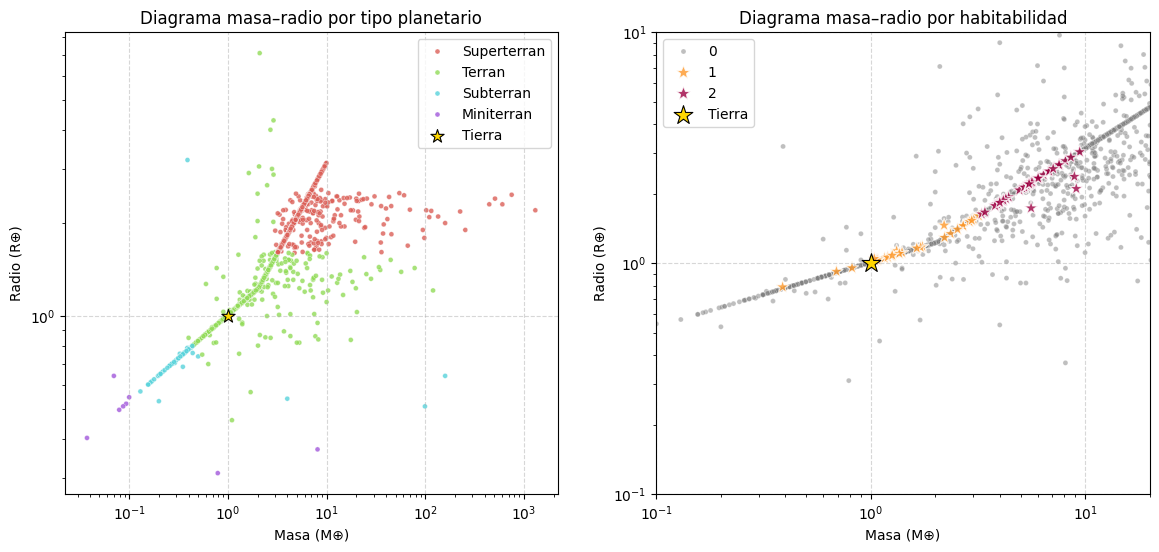

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(14,6))
# Scatter por tipo planetario
sns.scatterplot(data=df_types, y="P_RADIUS", x="P_MASS", hue="P_TYPE", s = 13, alpha = 0.8, palette = "hls", ax=ax1)
# Marcador de Tierra
ax1.scatter(1, 1, c='gold', s=100, marker='*', zorder=5, edgecolors='black', linewidth=0.8, label='Tierra')
# Ajustes
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Masa (M⊕)')
ax1.set_ylabel('Radio (R⊕)')
ax1.set_title('Diagrama masa–radio por tipo planetario')
ax1.legend()
ax1.grid(ls='--', alpha=0.5)

# Scatter por habitabilidad
sns.scatterplot(data=df_habitable[df_habitable["P_HABITABLE"].isin([0])], y="P_RADIUS", x="P_MASS", hue="P_HABITABLE", s = 13, alpha = 0.5, palette = "grey", ax=ax2)
sns.scatterplot(data=df_habitable[df_habitable["P_HABITABLE"].isin([1])], y="P_RADIUS", x="P_MASS", hue="P_HABITABLE", marker= '*',s = 100, alpha = 0.8, palette = "YlOrBr", ax=ax2)
sns.scatterplot(data=df_habitable[df_habitable["P_HABITABLE"].isin([2])], y="P_RADIUS", x="P_MASS", hue="P_HABITABLE", marker= '*',s = 100, alpha = 0.8, palette = "Spectral", ax=ax2)
# Marcador de Tierra
ax2.scatter(1, 1, c='gold', s=200, marker='*', zorder=5, edgecolors='black', linewidth=0.8, label='Tierra')
# Ajustes
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Masa (M⊕)')
ax2.set_ylabel('Radio (R⊕)')
ax2.set_title('Diagrama masa–radio por habitabilidad')
ax2.set_xlim(0.1, 20)
ax2.set_ylim(0.1, 10)
ax2.legend()
ax2.grid(ls='--', alpha=0.5)

plt.show()

En el primer gráfico los distintos tipos planetarios se dividen naturalmente variando su radio y masa. Mientras que en el segundo gráfico, podemos observar que los planetas forman una tendencia ordenada a medida que incrementa su masa y radio. Observamos una separación alrededor de las 2.5M⊕, donde pasado éste rango se considera que los planetas tienen un parámetro de habitabilidad más óptimista. Se interpreta que podría tener relación con la composición atmosférica; es necesario realizar un análisis a profundidad en trabajos futuros.

## 3.2 ¿Existe relación entre densidad media y velocidad de escape?

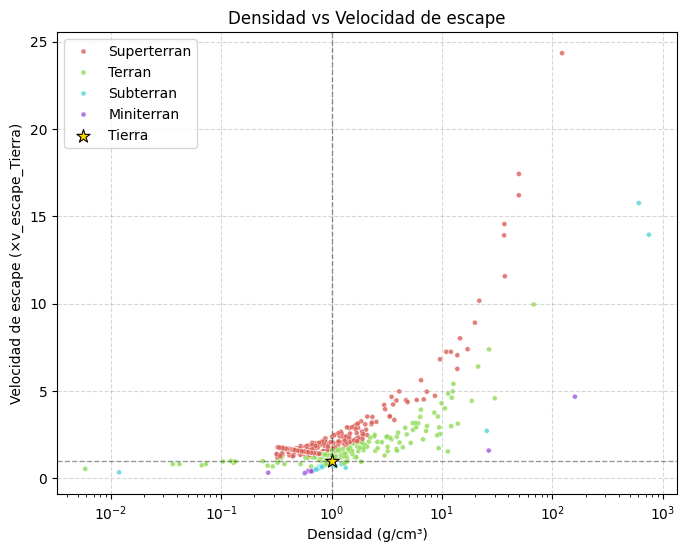

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(data=df_types, x="P_DENSITY", y="P_ESCAPE", hue="P_TYPE", s = 13, alpha = 0.8, palette = "hls")
ax.scatter(np.sqrt(tierra['densidad']), tierra['vel. escape'], c='gold', s=100, marker='*', zorder=5, edgecolors='black', linewidth=0.8, label='Tierra')
ax.axhline(tierra['vel. escape'], color='black', linestyle='--', alpha=0.4, lw=1)
ax.axvline(tierra['densidad'], color='black', linestyle='--', alpha=0.4, lw=1)
ax.set_xscale("log")
ax.set_xlabel('Densidad (g/cm³)')
ax.set_ylabel('Velocidad de escape (×v_escape_Tierra)')
ax.set_title('Densidad vs Velocidad de escape')
ax.legend()
ax.grid(ls='--', alpha=0.5)
plt.show()

Analizando el gráfico se puede apreciar una clara relación entre ambas variables: a medida que aumenta la densidad, aumenta la velocidad de escape, donde los tipos planetarios Superterra se ecnuentran por sobre los Terra, e inferiores, en cuanto a velocidad de escape se refiere.

## 3.2 ¿Cómo se distribuyen las temperaturas de equilibrio de los exoplanetas?

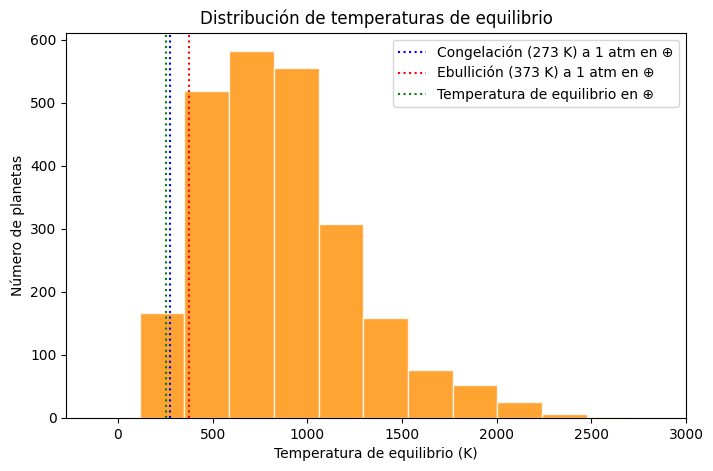

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_types['P_TEMP_EQUIL'].dropna(), bins=30, color='darkorange', edgecolor='white', alpha=0.8)
ax.axvline(x=273.15, color='blue', linestyle=':', linewidth=1.5, label='Congelación (273 K) a 1 atm en ⊕')
ax.axvline(x=373.15, color='red', linestyle=':', linewidth=1.5, label='Ebullición (373 K) a 1 atm en ⊕')
ax.axvline(x=255, color='green', linestyle=':', linewidth=1.5, label='Temperatura de equilibrio en ⊕')
ax.set_xlabel('Temperatura de equilibrio (K)')
ax.set_ylabel('Número de planetas')
ax.set_title('Distribución de temperaturas de equilibrio')
ax.legend()
ax.set_xlim(-273, 3000)
plt.show()

A partir del histograma, es posible observar que hay una gran concentración de planetas que se alejan considerablemente de los rangos óptimos para retener agua en estado líquido (aprox. 200K-300K, ya que la temperatura de equilibrio en la Tierra es de 255K).

## 3.3 ¿Qué combinación de masa y temperatura parece más favorable para retener atmósfera?

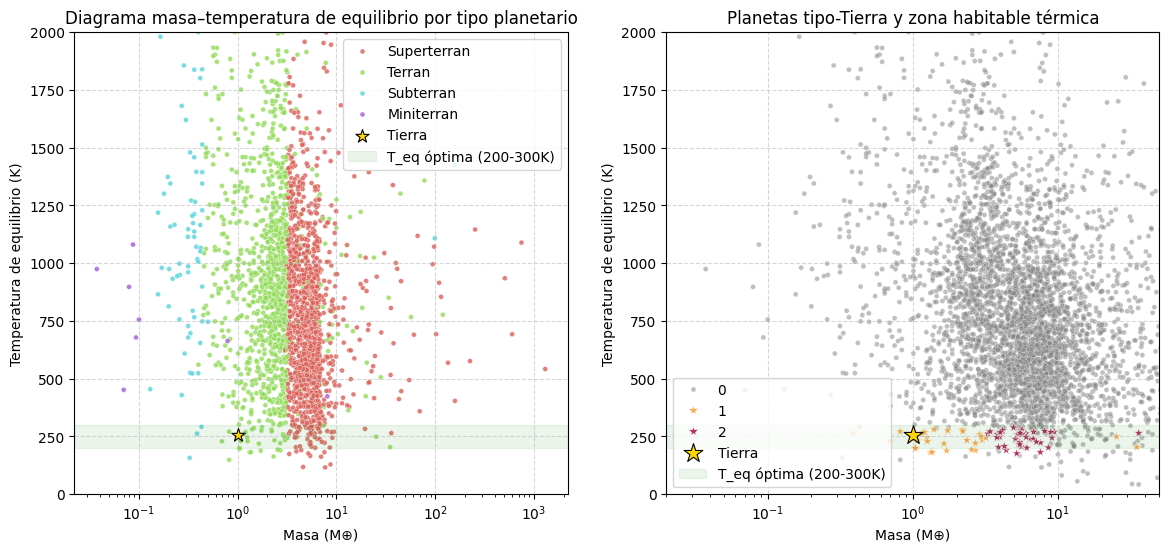

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2,figsize=(14,6))

# Gráfico por tipo planetario
sns.scatterplot(data=df_types, x="P_MASS", y="P_TEMP_EQUIL", hue="P_TYPE", s = 13, alpha = 0.8, palette = "hls", ax=ax1)
ax1.scatter(1, tierra['temp_equil'], c='gold', s=100, marker='*', zorder=5, edgecolors='black', linewidth=0.8, label='Tierra')
ax1.axhspan(200, 300, alpha=0.08, color='green', label='T_eq óptima (200-300K)')
ax1.set_xscale('log')
ax1.set_xlabel('Masa (M⊕)')
ax1.set_ylabel('Temperatura de equilibrio (K)')
ax1.set_title('Diagrama masa–temperatura de equilibrio por tipo planetario')
ax1.set_ylim(0,2000)
ax1.legend()
ax1.grid(ls='--', alpha=0.5)

# Gráfico por habitabilidad
sns.scatterplot(data=df_habitable[df_habitable["P_HABITABLE"].isin([0])], x="P_MASS", y="P_TEMP_EQUIL", hue="P_HABITABLE", s = 13, alpha = 0.5, palette = "grey", ax=ax2)
sns.scatterplot(data=df_habitable[df_habitable["P_HABITABLE"].isin([1])], x="P_MASS", y="P_TEMP_EQUIL", hue="P_HABITABLE", marker= '*',s = 50, alpha = 0.8, palette = "YlOrBr", ax=ax2)
sns.scatterplot(data=df_habitable[df_habitable["P_HABITABLE"].isin([2])], x="P_MASS", y="P_TEMP_EQUIL", hue="P_HABITABLE", marker= '*',s = 50, alpha = 0.8, palette = "Spectral", ax=ax2)
ax2.scatter(1, tierra['temp_equil'], c='gold', s=200, marker='*', zorder=5, edgecolors='black', linewidth=0.8, label='Tierra')

ax2.axhspan(200, 300, alpha=0.08, color='green', label='T_eq óptima (200-300K)')
ax2.set_xscale('log')
ax2.set_xlabel('Masa (M⊕)')
ax2.set_ylabel('Temperatura de equilibrio (K)')
ax2.set_title('Planetas tipo-Tierra y zona habitable térmica')
ax2.set_xlim(0.02, 50)
ax2.set_ylim(0, 2000)
ax2.legend()
ax2.grid(ls='--', alpha=0.5)

plt.show()

En base a lo que nos aporta el gráfico, podemos establecer que la masa no tiene relación directa con la temperatura en cuanto a la capacidad de retención atmosférica, pero sí se relacionan de forma indirecta a través de la velocidad de escape. Al momento de retener atmósfera, un planeta con altas temperaturas tiende a permitir que el gas escape más fácil, dado que la energía cinética de las particulas es mayor. Al mismo tiempo, en un planeta con temperaturas más bajas, la gravedad evita que las particulas escapen, dado que su energía cinética es más baja.

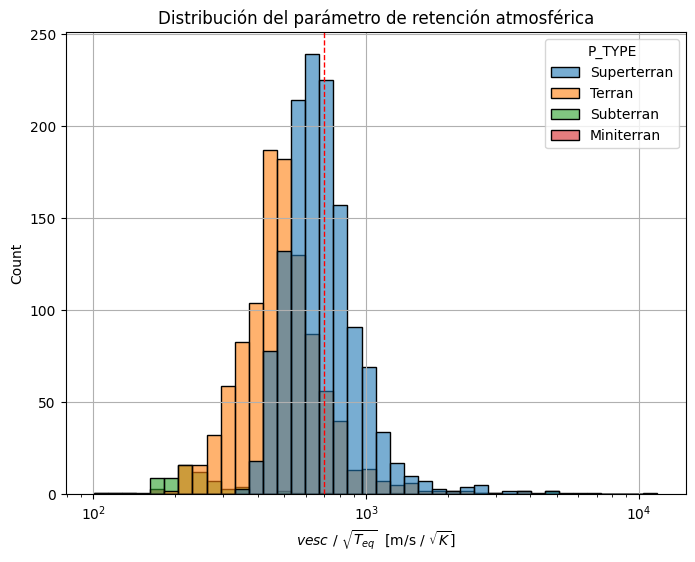

In [ ]:
v_esc_earth = 11186
df_types["P_ESCAPE_MS"] = df["P_ESCAPE"] * v_esc_earth
df_types["RAZON"] = df_types["P_ESCAPE_MS"] / np.sqrt(df_types["P_TEMP_EQUIL"])

fig, ax = plt.subplots(figsize=(8,6))

sns.histplot( data=df_types, x="RAZON", hue="P_TYPE", bins=40, alpha=0.6, log_scale=True, ax=ax)
ax.axvline(x=700.49, color='red', linestyle='--', linewidth=1, label="Razón retención de atmósfera Tierra")
ax.set_xlabel(r'$v{esc}$ / $\sqrt{T_{eq}}$  [(m/s) / $\sqrt{K}$]')
ax.set_title('Distribución del parámetro de retención atmosférica')
ax.grid()

plt.show()

Se definió la siguiente razón aproximada entre velocidad de escape y velocidad térmica de las partículas:

$$
\frac{v_{esc}}{\sqrt{T_{eq}}}
$$

La distribución indica que la mayoría de los planetas posee una capacidad de retención atmosférica similar a la de la Tierra (siendo este la línea vertical en rojo). Los valores más altos corresponden a planetas con mayor gravedad relativa, favoreciendo la retención atmosférica, mientras que valores bajos sugieren condiciones más favorables para el escape atmosférico.

## 3.4 ¿Cómo se comportan las incertidumbres de los valores de masa de los datos?

A continuación se visualiza un gráfico de masa junto a una barra vertical que representan sus incertidumbres respectivas en el eje y.

En algunos puntos se observa que existen rangos muy amplios, provocando desconfianza al momento de clasificarlos.

Por otro lado existen datos que no presentan incertidumbres, es importante recalcar que esto no significa que no tengan, si no que para estos valores no fue calculado o presentan NaN.

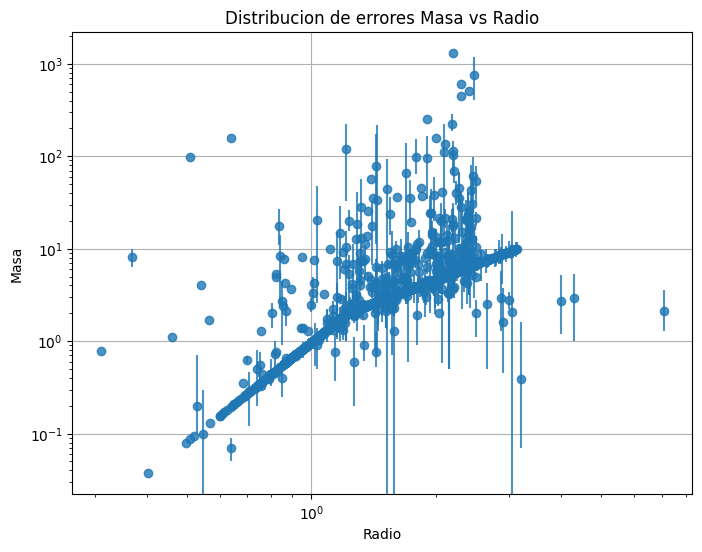

In [ ]:
err_inf = abs(df_types['P_MASS_ERROR_MIN'])
err_sup = df_types['P_MASS_ERROR_MAX']
fig, ax = plt.subplots(figsize=(8,6))
ax.errorbar(df_types['P_RADIUS'], df_types['P_MASS'], yerr=[err_inf, err_sup], fmt='o', alpha=0.8)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Radio")
ax.set_ylabel("Masa")
ax.set_title("Distribucion de errores Masa vs Radio")
ax.grid()
plt.show()

Se excluyeron planetas sin incertidumbres reportadas en las columnas de masa y radio. Los datos sin barras de incertidumbre no asegura si la medición es precisa o si el planeta podría tener en realidad una masa y radio insuficientes para retener atmósfera. Este filtro prioriza la fiabilidad de los candidatos sobre la cantidad de datos.

In [ ]:
df_clean2 = df_clean.dropna(subset=["P_MASS_ERROR_MIN", "P_MASS_ERROR_MAX", "P_RADIUS_ERROR_MIN","P_RADIUS_ERROR_MAX"])
df_types2 = df_clean2[df_clean2["P_TYPE"].isin(tipos)].copy()

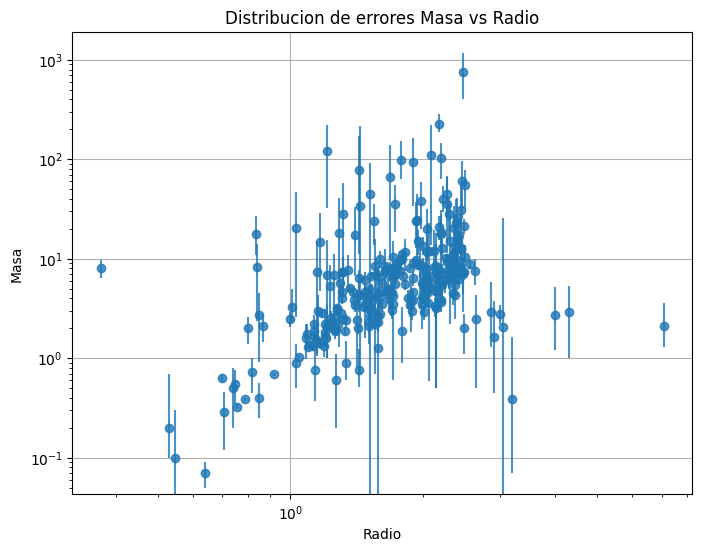

In [ ]:
err_inf2 = abs(df_types2['P_MASS_ERROR_MIN'])
err_sup2 = df_types2['P_MASS_ERROR_MAX']
fig, ax = plt.subplots(figsize=(8,6))
ax.errorbar(df_types2['P_RADIUS'], df_types2['P_MASS'], yerr=[err_inf2, err_sup2], fmt='o', alpha=0.8)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Radio")
ax.set_ylabel("Masa")
ax.set_title("Distribucion de errores Masa vs Radio")
ax.grid()
plt.show()

Dado que el objetivo es identificar los 3 mejores candidatos a retener atmósfera y poseer agua en estado líquido, no basta con utilizar datos favorables. Es necesario que esos datos estén respaldados por mediciones más precisas. Planetas con incertidumbres mayores a 50% podrían en realidad tener masas, radios o temperaturas muy distintos a las reportadas, lo que los convierte en candidatos poco fiables. Por esta razón, restringimos nuestra selección a planetas con errores relativos inferiores al 50% en las categorías de masa y radio.

In [ ]:
umbral_error = 0.50 #50%

# Error relativo para la masa
error_rel_masa_min = df_types2['P_MASS_ERROR_MIN'].abs() / df_types2['P_MASS']
error_rel_masa_max = df_types2['P_MASS_ERROR_MAX'] / df_types2['P_MASS']

# Error relativo para el radio
error_rel_radio_min = df_types2['P_RADIUS_ERROR_MIN'].abs() / df_types2['P_RADIUS']
error_rel_radio_max = df_types2['P_RADIUS_ERROR_MAX'] / df_types2['P_RADIUS']

mask_error = (
    (error_rel_masa_min <= umbral_error) &
    (error_rel_masa_max <= umbral_error) &
    (error_rel_radio_min <= umbral_error) &
    (error_rel_radio_max <= umbral_error))

# Aplicamos mask
df_filtrado_error = df_types2[mask_error].copy()

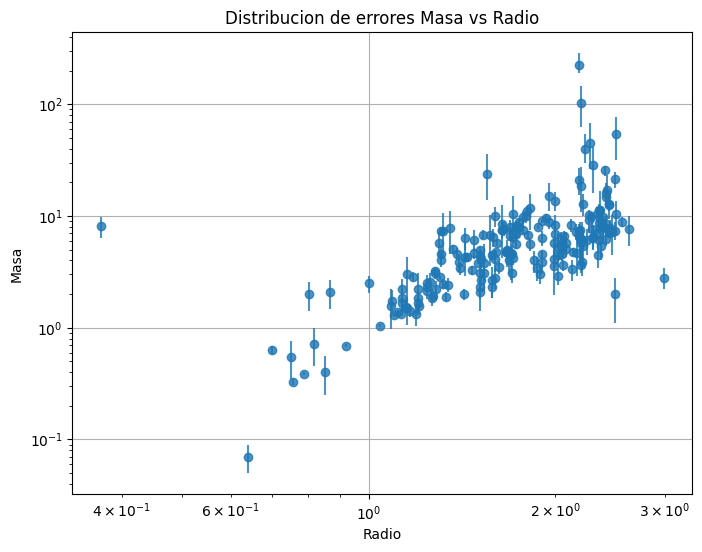

In [ ]:
err_inf3 = abs(df_filtrado_error['P_MASS_ERROR_MIN'])
err_sup3 = df_filtrado_error['P_MASS_ERROR_MAX']
fig, ax = plt.subplots(figsize=(8,6))
ax.errorbar(df_filtrado_error['P_RADIUS'], df_filtrado_error['P_MASS'], yerr=[err_inf3, err_sup3], fmt='o', alpha=0.8)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Radio")
ax.set_ylabel("Masa")
ax.set_title("Distribucion de errores Masa vs Radio")
ax.grid()
plt.show()

Luego de aplicar la eliminación de datos NaN, y filtrar los datos por un umbral de 0.5, el tamaño final del data set resultó en 204 planetas.

In [ ]:
print("Tamaño df filtrado NaN:", len(df_types2))
print("Tamaño df filtrado porcentaje:", len(df_filtrado_error))

Tamaño df filtrado NaN: 277
Tamaño df filtrado porcentaje: 204


Este mismo proceso de limpieza se aplicó para las incertidumbres del radio.

Luego de aplicar la preparación y limpieza del dataset, en la siguiente sección se explicará el criterio para la selección de los candidatos a planetas habitables.

# **4. Selección de candidatos**


**Para la selección final de los mejores candidatos a planetas habitables, se empleó una metodología de puntuación basada en los parámetros planetológicos analizados, considerando tanto lo observado en los gráficos exploratorios como la similitud de cada variable con los valores terrestres de referencia, ya que la Tierra es el único referente empírico de habitabilidad que tenemos.**

In [ ]:
candidatos= df_filtrado_error.copy()

# Normalización de variables para scoring (0 = peor, 1 = mejor)
def norm_col(series, ascending=True):
    """Normaliza una columna a [0,1]. ascending=True -> mayor valor, mejor score."""
    s = series.copy().fillna(series.median())
    if s.max() == s.min():
        return pd.Series(0.5, index=series.index)
    if ascending:
        return (s - s.min()) / (s.max() - s.min())
    else:
        return 1 - (s - s.min()) / (s.max() - s.min())

# Penalización por masa muy alta (queremos 0.5–5 M⊕ idealmente, por el tema de la retención atmosférica)
def score_masa(m):
    """Función de penalización gaussiana centrada en 1 M⊕."""
    return np.exp(-0.5 * ((np.log10(m) - 0) / 0.7)**2)

# Penalización por temperatura fuera de rango
def score_temp(t):
    """Score máximo en 250 K, decayendo hacia los extremos."""
    if pd.isna(t):
        return 0.5
    return np.exp(-0.5 * ((t - 255) / 80)**2)

In [ ]:
candidatos['score_masa'] = candidatos['P_MASS'].apply(score_masa)
candidatos['score_dens'] = norm_col(candidatos['P_DENSITY'], ascending=True)
candidatos['score_temp'] = candidatos['P_TEMP_EQUIL'].apply(score_temp)
candidatos['score_hab']  = candidatos['P_HABITABLE'].map({1: 0.5, 2: 1.0})

candidatos['SCORE_TOTAL'] = (
    0.25 * candidatos['score_masa'] +
    0.25 * candidatos['score_dens'] +
    0.25 * candidatos['score_temp'] +
    0.25 * candidatos['score_hab']
)

In [ ]:
# Valores de la Tierra como fila de referencia
tierra_row = {
    'P_NAME': 'Tierra (referencia)',
    'P_TYPE': 'Terran',
    'P_MASS': 1.0,
    'P_RADIUS': 1.0,
    'P_DENSITY': 1.0,
    'P_GRAVITY': 1.0,
    'P_ESCAPE': 1.0,
    'P_TEMP_EQUIL': 255.0,
    'P_HABITABLE': 1,
    'P_ESI': 1.0,
    'SCORE_TOTAL': float('nan')  # No aplica
}
tierra_df= pd.DataFrame([tierra_row])

In [ ]:
# Ranking final
ranking = candidatos.sort_values('SCORE_TOTAL', ascending=False)[
    ['P_NAME', 'P_TYPE', 'P_MASS', 'P_RADIUS', 'P_DENSITY',
     'P_GRAVITY', 'P_ESCAPE', 'P_TEMP_EQUIL', 'P_HABITABLE',
     'P_ESI', 'SCORE_TOTAL']
].reset_index(drop=True)

ranking_final = pd.concat(
    [ranking.head(10), tierra_df, ranking.iloc[10:]],
    ignore_index=True
)
ranking_final.index = ranking_final.index + 1
print('\nTop 10 candidatos según score compuesto:')
ranking_final.head(11).round(3)


Top 10 candidatos según score compuesto:


,P_NAME,P_TYPE,P_MASS,P_RADIUS,P_DENSITY,P_GRAVITY,P_ESCAPE,P_TEMP_EQUIL,P_HABITABLE,P_ESI,SCORE_TOTAL
1,TRAPPIST-1 e,Terran,0.692,0.920,0.889,0.818,0.867,228.447,1,0.845,0.606
2,LHS 1140 b,Superterran,5.600,1.730,1.082,1.871,1.799,205.638,2,0.658,0.599
3,K2-18 b,Superterran,8.920,2.370,0.670,1.588,1.940,268.063,2,0.701,0.597
4,TRAPPIST-1 d,Subterran,0.388,0.788,0.793,0.625,0.702,261.811,1,0.908,0.586
5,TRAPPIST-1 f,Terran,1.039,1.045,0.910,0.951,0.997,199.147,1,0.677,0.572
6,TRAPPIST-1 g,Terran,1.321,1.129,0.918,1.036,1.082,180.546,1,0.576,0.535
7,TOI-238 b,Terran,3.400,1.402,1.234,1.730,1.557,1331.986,0,0.285,NaN
8,TOI-1470 b,Superterran,7.320,2.180,0.707,1.540,1.832,660.577,0,0.272,NaN
9,HD 86226 c,Superterran,7.250,2.160,0.719,1.554,1.832,1199.082,0,0.249,NaN
10,55 Cnc e,Superterran,7.990,1.875,1.212,2.273,2.064,1830.030,0,0.261,NaN


In [ ]:
# Perfil detallado de los 3 mejores candidatos
top3 = ranking.head(3)

print('\nPerfil detallado de los 3 mejores candidatos:\n')

tierra_vals = {
    'P_MASS': 1.0, 'P_RADIUS': 1.0, 'P_DENSITY': 1.0,
    'P_GRAVITY': 1.0 , 'P_ESCAPE': 1.0, 'P_TEMP_EQUIL': 255, 'P_ESI': 1.0
}

for i, (_, row) in enumerate(top3.iterrows(), 1):
    print(f'\n  #{i}: {row["P_NAME"]} (Score: {row["SCORE_TOTAL"]:.3f})')
    print(f'  Tipo: {row["P_TYPE"]}  |  P_HABITABLE: {row["P_HABITABLE"]}')
    print(f'  ESI: {row["P_ESI"]:.3f}')
    print(f'  Masa:          {row["P_MASS"]:.2f} M⊕  (Tierra: {tierra_vals["P_MASS"]})')
    print(f'  Radio:         {row["P_RADIUS"]:.2f} R⊕  (Tierra: {tierra_vals["P_RADIUS"]})')
    print(f'  Densidad:      {row["P_DENSITY"]:.2f} g/cm³  (Tierra: {tierra_vals["P_DENSITY"]})')
    print(f'  Gravedad:      {row["P_GRAVITY"]:.2f} m/s²  (Tierra: {tierra_vals["P_GRAVITY"]})')
    print(f'  V. escape:     {row["P_ESCAPE"]:.3f} ×v⊕  (Tierra: 1.0)')
    t_eq = f'{row["P_TEMP_EQUIL"]:.0f} K' if not pd.isna(row['P_TEMP_EQUIL']) else 'N/D'
    print(f'  Temp. equilib: {t_eq}  (Tierra: {tierra_vals["P_TEMP_EQUIL"]} K)')
    print()


Perfil detallado de los 3 mejores candidatos:


  #1: TRAPPIST-1 e (Score: 0.606)
  Tipo: Terran  |  P_HABITABLE: 1
  ESI: 0.845
  Masa:          0.69 M⊕  (Tierra: 1.0)
  Radio:         0.92 R⊕  (Tierra: 1.0)
  Densidad:      0.89 g/cm³  (Tierra: 1.0)
  Gravedad:      0.82 m/s²  (Tierra: 1.0)
  V. escape:     0.867 ×v⊕  (Tierra: 1.0)
  Temp. equilib: 228 K  (Tierra: 255 K)


  #2: LHS 1140 b (Score: 0.599)
  Tipo: Superterran  |  P_HABITABLE: 2
  ESI: 0.658
  Masa:          5.60 M⊕  (Tierra: 1.0)
  Radio:         1.73 R⊕  (Tierra: 1.0)
  Densidad:      1.08 g/cm³  (Tierra: 1.0)
  Gravedad:      1.87 m/s²  (Tierra: 1.0)
  V. escape:     1.799 ×v⊕  (Tierra: 1.0)
  Temp. equilib: 206 K  (Tierra: 255 K)


  #3: K2-18 b (Score: 0.597)
  Tipo: Superterran  |  P_HABITABLE: 2
  ESI: 0.701
  Masa:          8.92 M⊕  (Tierra: 1.0)
  Radio:         2.37 R⊕  (Tierra: 1.0)
  Densidad:      0.67 g/cm³  (Tierra: 1.0)
  Gravedad:      1.59 m/s²  (Tierra: 1.0)
  V. escape:     1.940 ×v⊕  (Tierra: 1.0)


# **5. Conclusiones**

**Luego del análisis planetológico, enfocándonos en la capacidad de retención atmosférica y la posibilidad de encontrar agua en estado líquido, obtenemos que los candidatos más prometedores corresponden a los exoplanetas TRAPPIST-1e, LHS 1140 b y K2-18 b.**

**TRAPPIST-1e:**

Según el enfoque del proyecto este exoplaneta resultó ser nuestro mejor candidato.  \
Existe un amplio consenso en las investigaciones de los últimos años en cuanto a la similitud planetológica que tiene respecto a la Tierra: posee el 91% de su radio, 77% de la masa y el 102.4% de la densidad media, además de una similitud del 93% de la gravedad superficial. Adicionalmente, la temperatura oscila entre los rangos de 225 K a 246 K con evidencias que señalan que es suficientemente frio para poseer agua en estado líquido en su superficie y una atmósfera con habitabilidad óptima.

**LHS 1140 b:**

Estudios recientes sobre este exoplaneta potencian nuestro hallazgo, aunque posee propidades particulares tales como que tiene más de 5 veces la masa de la Tierra y el doble de su radio, lo que convertiría a LHS 1140-b en un planeta oceánico o similar a un minineptuno, y no tanto así a un planeta rocoso.
Sin embargo, observaciones han indicado la posibilidad de la existencia de agua líquida en su cara iluminada, lo que valida nuestro criterio de selección.

**K2-18 b:**

Este es un exoplaneta que se encuentra en una masa límite entre supertierra y subneptuno. Tiene un radio aproximado de 2,37 radios terrestres, por lo que entra en el radius valley (rango de tamaños de exoplanetas entre ≈1,5–2,5 R⊕ donde hay menos planetas, separando las supertierras de los subneptunos.) y su información es más escasa. Es por esto que sus características le restan puntos en nuestro ranking y lo sitúan último en la clasificación. Según observaciones del telescopio James Webb, se han encontrado moléculas de metano y de dióxido de carbono, lo que sugiere que este podría tratarse de un planeta oceánico. Por lo que se necesitan más investigaciones para confirmar si estamos ante un planeta potencialmente habitable

# **6. Bibliografía**

- Magnetohydrodynamic simulations preliminarily predict the habitability and radio emission of TRAPPIST-1e
BoRui Wang, ShengYi Ye, Jacobo Varela and XinYi Luo
A&A, 701 (2025) A264
doi: https://doi.org/10.1051/0004-6361/202555471

- Damiano M, Bello-Arufe A, Yang J, Hu R. 2024. LHS 1140 b is a potentially habitable water world. Astrophys J Lett; 968:L22.
doi: 10.3847/2041-8213/ad5204.

- Madhusudhan N, et al. 2023. Carbon-bearing molecules in a possible Hycean atmosphere.
doi: https://doi.org/10.48550/arXiv.2309.05566

- Kossakowski D, Kürster M, Trifonov T, Henning T, Kemmer J, Caballero JA, Burn R, Sabotta S, Crouse JS, Fauchez TJ, et al. 2023. The CARMENES search for exoplanets around M dwarfs. doi:10.1051/0004-6361/202245322.

- NASA Exoplanet Science Institute. 2026. NASA Exoplanet Science Institute [Internet]. Pasadena (CA): Caltech; [accedido 2026 mayo 4]. Disponible en: https://nexsci.caltech.edu/

- PHL @ UPR Arecibo. 2026. The Habitable Worlds Catalog (HWC) [Internet]. [accedido 2026 mayo 4]. Disponible en: http://phl.upr.edu/hwc